In [1]:
import sys
sys.path.append("../ingestion/python/src")
sys.path.append("../ingestion/python/LangGraph_Agent")

from utils import *
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

from silver_enrichment import *
from graph_silver_enrichment import *
from APIendpoint import PlacesAPI
from database import Database

import os
from dotenv import load_dotenv
load_dotenv(override=True)

llm = LLM()
places_api = PlacesAPI(os.getenv('MAPS_APP_KEY'))
db = Database()

c:\APPS\Python312\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


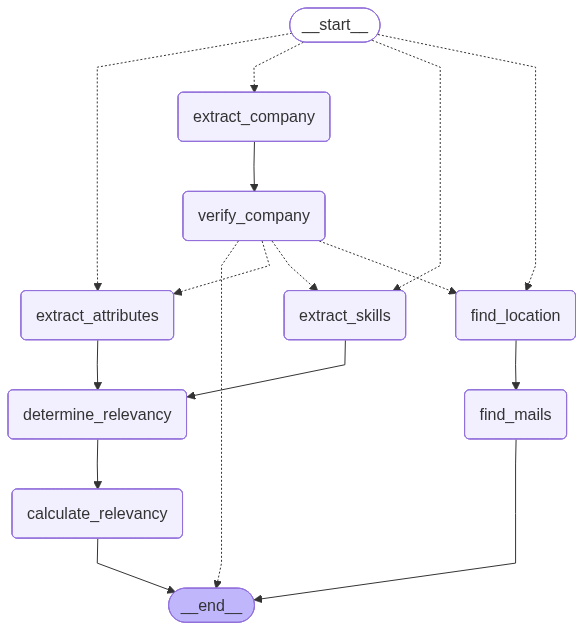

In [2]:

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
raw = db.execute('SELECT * FROM raw.job_offer LIMIT 1')
states = []
for row in raw:
    states.append(map_bronze_to_JobOfferState(row))

In [4]:
result = []
for state in states:
    result.append(graph.invoke(state))

Loading formatted geocoded file...


In [5]:
import json
from functools import reduce
import datetime
# Fusion en un seul dictionnaire
dico_unique = reduce(lambda x, y: x | y, result)
nom_fichier = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
write_json('./test_graph',nom_fichier, dico_unique)
result


[{'id_job': 'cj_dbeff1c6682c16cb814f',
  'id_company': None,
  'id_location': None,
  'api_source': 'careerjet',
  'job_title': 'Analytics Engineer SSR (Buenos Aires)',
  'offer_description': ' o más años de experiencia en roles de <b>Data</b> <b>Engineer</b>, Analytics <b>Engineer</b> o BI Developer. (excluyente)  - Experiencia previa en tecnologías Cloud... y transformar datos para optimizar su consumo analítico, aplicando buenas prácticas de <b>data</b> warehousing.  - Desarrollar dashboards',
  'contract_type': 'unknown',
  'is_remote': False,
  'job_publisher': None,
  'location_raw': 'Buenos Aires',
  'offer_url': 'https://jobviewtrack.com/v2/SpgczSBaspeLt8tt4UUF2LdwdeaDDBlLp22lhh2OU1rnRXVaG8odVAC93F6tg3iBE7vZm5_N5GMNLiC68X3mJfLld0rFk2yPbbJh5Uxb6bAXF8T7pnUVc-2G6by87qHhX_6r5v0RX6hDCUykn4Mc_gtYcUdXy3b9lltPjCH9xApLwFMmlEjQ98AlZfKrDHpTWNT4IX3Ak_i_e7vQR7tTvLYXEQzMY9V-yhSS0UKSNS0',
  'source_platform': None,
  'offer_language': ['es'],
  'published_at': '2026-05-30 22:19:44+00',
  'col